In [ ]:
"""
Clasificador de dígitos con una Red Neuronal Convolucional (CNN)
Objetivo:
Construir una Convolutional Neural Network (CNN) utilizando PyTorch para clasificar imágenes del dataset MNIST. La CNN aprenderá automáticamente filtros capaces de detectar patrones visuales como bordes, líneas, curvas y formas, preservando la estructura espacial de la imagen.
Imagen 1x28x28
      │
      ▼
Conv2d (1 → 16, kernel=3)
      │16x26x26
      │
ReLU
      │16x26x26
      │
MaxPool2d (2)
      │16x13x13
      │
Conv2d (16 → 32, kernel=3)
      │32x11x11
      │
ReLU
      │32x11x11
      │
MaxPool2d (2)
      │32x5x5
      │
Flatten
      │800
      │
Linear (800 → 128)
      │
ReLU
      │
Linear (128 → 10)
      │
      ▼
10 logits
"""

import torch
from torch import nn
import torch.optim as optim

from torchvision import datasets
from torchvision.transforms import ToTensor

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100.0%
100.0%
100.0%
100.0%


## Preparación de datos y arquitectura CNN

En esta primera parte se carga MNIST, se dejan listos los tensores de entrada y se define la base sobre la que trabaja la red convolucional.

In [ ]:
def train(model, train_loader, criterion, optimizer, epochs=10):
    model.train() # Cambia el modelo a modo entrenamiento
    
    loss_history = []
    accuracy_history = []
    
    for epoch in range(epochs):
        correct = 0 # Cantidad de imágenes clasificadas correctamente.
        total = 0 # Cantidad total de imágenes procesadas.
        total_loss = 0 # Suma del loss de todos los batches de la época.
        
        for images, labels in train_loader:
            optimizer.zero_grad() # Reinicia los gradientes acumulados del paso anterior.
            logits = model(images) # Forward: obtiene los logits del modelo.
            loss = criterion(logits, labels) # Calcula la pérdida comparando logits vs etiquetas reales.
            loss.backward() # Backpropagation: Calcula automáticamente todos los gradientes.
            optimizer.step() # Actualiza pesos de las convoluciones, de las capas densas y bias utilizando esos gradientes.
            
            total_loss += loss.item() # Acumula el loss de este batch.
            predictions = logits.argmax(dim=1) # Elige el logit más grande de cada imagen. Esa será la clase predicha.
            correct += (predictions == labels).sum().item() # Cuenta cuántas imágenes fueron clasificadas correctamente.
            total += labels.size(0) # Acumula la cantidad total de imágenes vistas.

        loss_history.append(total_loss / len(train_loader)) # Loss promedio considerando todos los batches.
        accuracy_history.append(correct / total) # Porcentaje de aciertos sobre todo el dataset.

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"- Loss: {loss_history[-1]:.4f} "
            f"- Accuracy: {accuracy_history[-1]*100:.2f}%"
        )
    
    return loss_history, accuracy_history

def evaluate(model, eval_loader):
    model.eval() # Cambia el modelo a modo evaluación
    
    correct = 0
    total = 0
    
    with torch.no_grad(): # Desactiva el cálculo de gradientes para ahorrar memoria y computación.
        for images, labels in eval_loader:
            logits = model(images) # En evaluación solo hacemos forward pass; no actualizamos pesos.

            # La clase predicha vuelve a salir del logit de mayor valor.
            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
    accuracy = correct / total # Accuracy global sobre todo el loader.
            
    print(f"Accuracy: {accuracy*100:.2f}%")   
    
    # Si el loader contiene una sola imagen, además de la métrica global mostramos una lectura más interpretativa de la predicción puntual.
    if len(eval_loader) == 1:
          print(f"Imagen real: {labels[0].item()}")
          print(f"Imagen predicha: {predictions[0].item()}")
          print(f"Logits: {logits[0].tolist()}")
    
          # Convierte logits en probabilidades usando softmax
          probabilities = torch.nn.functional.softmax(logits[0], dim=0)
          print("Probabilidades de predicción:")
          for i, prob in enumerate(probabilities):
              print(f"  Clase {i}: {prob.item()*100:.2f}%")
    
          # Muestra la imagen
          plt.figure(figsize=(2,2))
          plt.imshow(images[0].squeeze().cpu().numpy(), cmap='gray')
          plt.title(f"Real: {labels[0].item()}, Predicha: {predictions[0].item()}")
          plt.axis('off')
          plt.show()
          
    return accuracy

In [ ]:
model = nn.Sequential(
    # Primera capa convolucional: aprende 16 filtros de 3x3 sobre la imagen de entrada. Como no hay padding y el kernel es 3, la salida pasa de 28x28 a 26x26.
    nn.Conv2d(1, 16, 3), 
    nn.MaxPool2d(2), # Reduce a la mitad la resolución espacial y conserva la información más relevante.
    
    # Segunda convolución: toma los 16 mapas anteriores y aprende 32 patrones más abstractos. El tamaño espacial vuelve a reducirse: 13x13 -> 11x11.
    nn.Conv2d(16, 32, 3), 
    nn.MaxPool2d(2), # Segundo pooling para comprimir la representación y hacerla más robusta a pequeñas variaciones.
    
    nn.Flatten(), # Convierte los 32 mapas de activación de 5x5 en un vector plano para poder usar capas densas.
    
    # Después de las dos capas convolucionales y los pooling, el tensor queda en 32x5x5. Eso da 800 características de entrada para la capa fully connected.
    nn.Linear(800, 128),
    nn.ReLU(), # Activación no lineal para que la red pueda combinar los patrones aprendidos por la CNN.
    
    nn.Linear(128, 10) # Capa final: devuelve 10 logits, uno por cada clase del dígito 0 al 9.
)

# CrossEntropyLoss es la función estándar para clasificación multiclase con logits crudos. No hace falta aplicar softmax antes, porque la función ya lo integra internamente.
criterion = nn.CrossEntropyLoss()
# Adam ajusta los pesos de la red de forma adaptativa y suele converger rápido en este tipo de problema.
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Se crean batches de 64 imágenes y se mezclan en cada época para mejorar el entrenamiento.
dataloader_train = torch.utils.data.DataLoader(training_data, batch_size=64, shuffle=True)

# Llama al ciclo de entrenamiento definido arriba y guarda la evolución de pérdida y accuracy.
loss_hty_train, accuracy_hty_train = train(model, dataloader_train, criterion, optimizer)

Epoch 1/10 - Loss: 0.2250 - Accuracy: 93.40%
Epoch 2/10 - Loss: 0.0573 - Accuracy: 98.28%
Epoch 3/10 - Loss: 0.0388 - Accuracy: 98.79%
Epoch 4/10 - Loss: 0.0297 - Accuracy: 99.06%
Epoch 5/10 - Loss: 0.0220 - Accuracy: 99.30%
Epoch 6/10 - Loss: 0.0184 - Accuracy: 99.39%
Epoch 7/10 - Loss: 0.0141 - Accuracy: 99.53%
Epoch 8/10 - Loss: 0.0128 - Accuracy: 99.57%
Epoch 9/10 - Loss: 0.0106 - Accuracy: 99.63%
Epoch 10/10 - Loss: 0.0090 - Accuracy: 99.69%


Accuracy: 98.92%
Accuracy: 100.00%
Imagen real: 9
Imagen predicha: 9
Logits: [-20.47068214416504, -11.404789924621582, -14.347220420837402, -9.78013801574707, 6.647702693939209, -9.372079849243164, -15.80675983428955, -2.8391993045806885, 0.4400366544723511, 10.23387622833252]
Probabilidades de predicción:
  Clase 0: 0.00%
  Clase 1: 0.00%
  Clase 2: 0.00%
  Clase 3: 0.00%
  Clase 4: 2.70%
  Clase 5: 0.00%
  Clase 6: 0.00%
  Clase 7: 0.00%
  Clase 8: 0.01%
  Clase 9: 97.30%


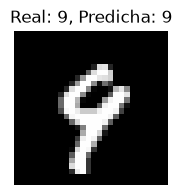

In [47]:
from random import randint

dataloader_eval = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=True)
accuracy = evaluate(model, dataloader_eval)

print("==================================================================================================================")
dataloader_eval_one = torch.utils.data.DataLoader([test_data[randint(1, len(test_data))]], batch_size=1, shuffle=True)
accuracy = evaluate(model, dataloader_eval_one)

## Análisis de resultados

Acá se grafican las métricas de entrenamiento y se construye la matriz de confusión para ver dónde la CNN acierta y en qué dígitos se sigue confundiendo.

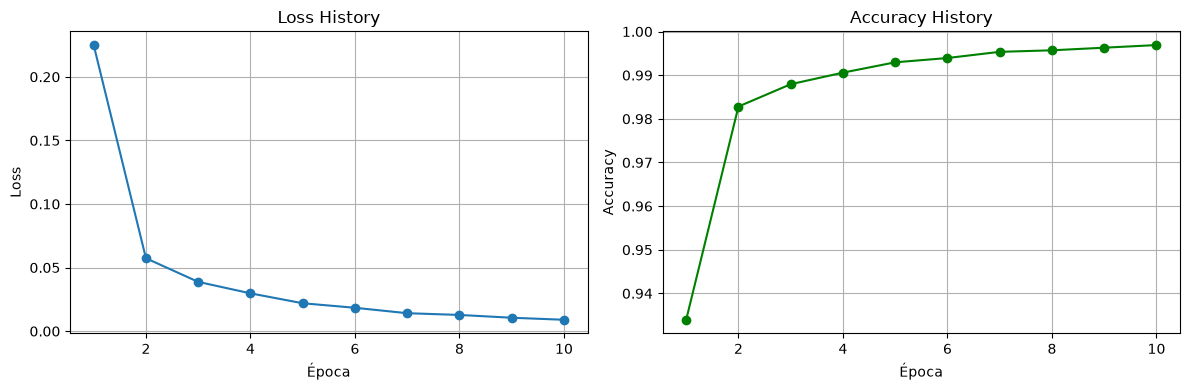

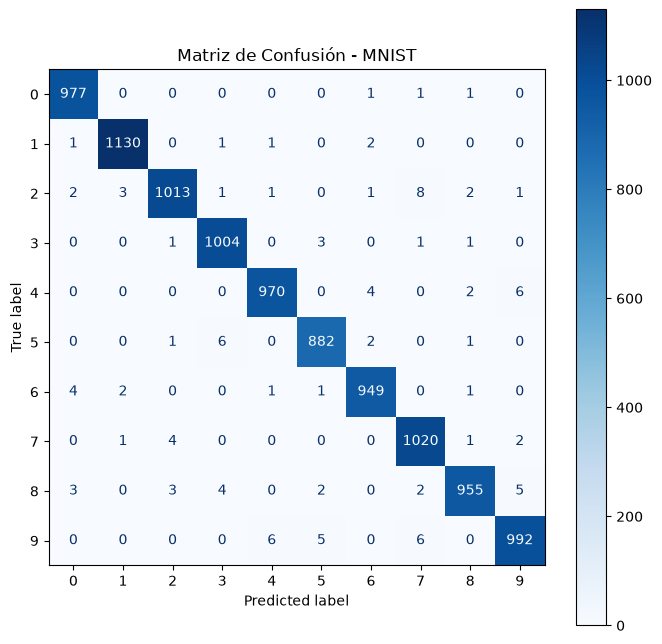

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================
# Gráficos de entrenamiento
# =========================
epochs = range(1, len(loss_hty_train) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(epochs, loss_hty_train, marker="o")
ax[0].set_title("Loss History")
ax[0].set_xlabel("Época")
ax[0].set_ylabel("Loss")
ax[0].grid(True)

ax[1].plot(epochs, accuracy_hty_train, marker="o", color="green")
ax[1].set_title("Accuracy History")
ax[1].set_xlabel("Época")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True)

plt.tight_layout()
plt.show()

# =========================
# Matriz de confusión
# =========================
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in dataloader_eval:
        logits = model(images)
        predictions = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Matriz de Confusión - MNIST")
plt.show()

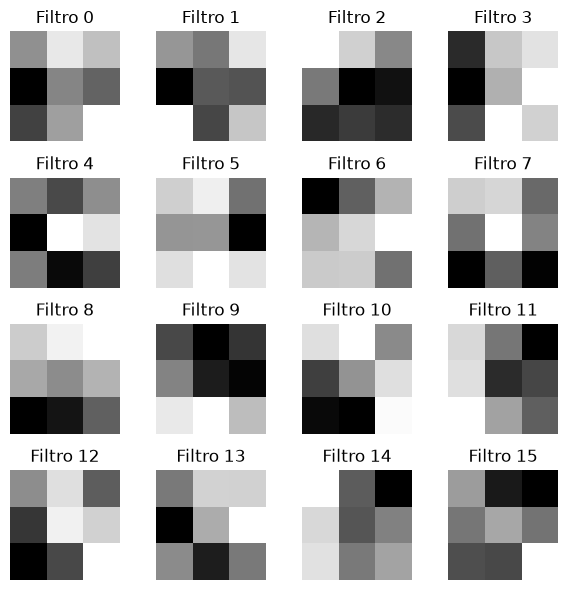

In [56]:
filters = model[0].weight.data
# print(filters.shape)

fig, axes = plt.subplots(4,4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i,0].cpu(), cmap="gray")
    ax.set_title(f"Filtro {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

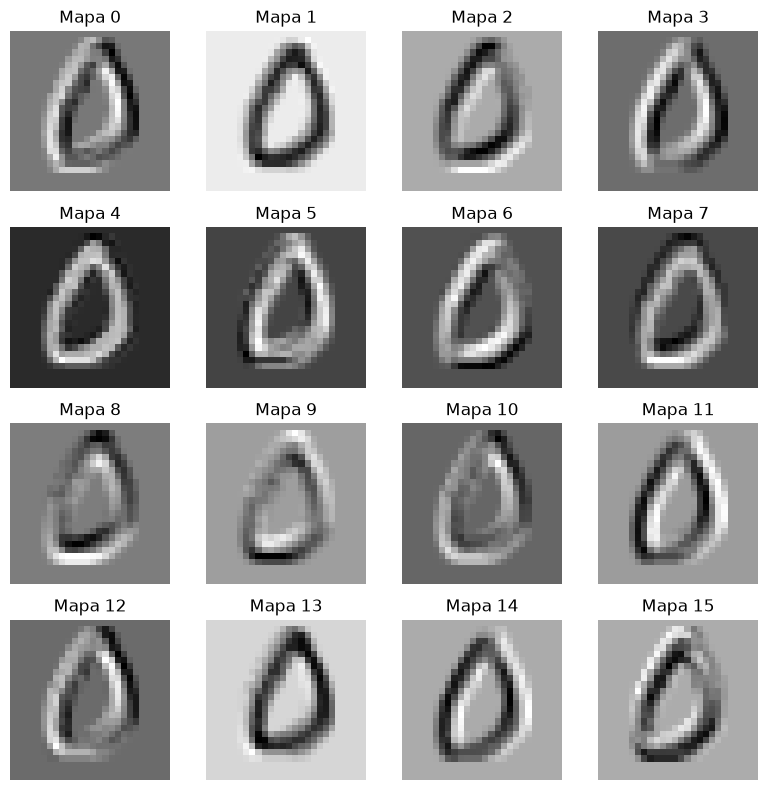

In [66]:
imagen, etiqueta = test_data[randint(1, len(test_data))]
imagen = imagen.unsqueeze(0)
activaciones = model[0](imagen)
# print(activaciones.shape)

fig, axes = plt.subplots(4,4, figsize=(8,8))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        activaciones[0, i].detach().numpy(),
        cmap="gray"
    )
    ax.set_title(f"Mapa {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()